# Broadcast complexity comparison

This notebook compares rank-fixed server time-complexity proxies as the matrix dimensions grow. Let $m=d_{\mathrm{out}}$, $n=d_{\mathrm{in}}$, $R$ be the fixed maximum global rank, and $r$ be the fixed client rank. The plotted default uses square matrices $m=n=d$ with $R=r=32$.

The deterministic work proxies are

$$C_{\mathrm{RBLA}}(m,n)=1=O(1),$$

$$C_{\mathrm{SP+}}(m,n)=(m+n)R^2+R^3+(m+n)Rr=O(m+n),$$

$$C_{\mathrm{DenseTrunc}}(m,n)=mnR+mnr=O(mn),$$

$$C_{\mathrm{FullSVD}}(m,n)=mnR+mn\min(m,n).$$

These are analytical leading-order work units, not measured runtime or hardware-exact FLOPs. The RBLA term assumes constant-time prefix views. Common factor serialization/communication is excluded. Both dense paths include materializing $B_gA_g$ in $mnR$ work. The truncated curve then uses an optimistic rank-$r$ SVD cost $mnr$, while the full-SVD curve uses $mn\min(m,n)$. For square matrices, the four plotted orders are $O(1)$, $O(d)$, $O(d^2)$, and $O(d^3)$.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

# Rank is fixed while the square projection dimension grows.
R = 32
CLIENT_RANK = 32
DIMENSIONS = np.array([128, 256, 512, 1024, 2048, 4096, 8192], dtype=int)

cwd = Path.cwd().resolve()
if cwd.name == "complexity_comparison":
    OUTPUT_DIR = cwd
else:
    OUTPUT_DIR = cwd / "rbla+" / "figures" / "complexity_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
paper_font = "Times New Roman" if "Times New Roman" in available_fonts else "DejaVu Serif"
mpl.rcParams.update({
    "font.family": paper_font,
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.45,
    "lines.markersize": 4.2,
    "grid.color": "0.75",
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.55,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

print(f"Output directory: {OUTPUT_DIR}")
print(f"Fixed ranks: R={R}, r={CLIENT_RANK}")
print(f"Square matrix dimensions: {DIMENSIONS.tolist()}")

Output directory: H:\paper-experiment-record\rbla+\figures\complexity_comparison
Fixed ranks: R=32, r=32
Square matrix dimensions: [128, 256, 512, 1024, 2048, 4096, 8192]


In [2]:
METHODS = (
    "RBLA index prefix",
    "SP+ (compact QR)",
    "Dense truncated SVD",
    "Full dense SVD",
)
EXPRESSIONS = {
    "RBLA index prefix": "1 (constant-time prefix view)",
    "SP+ (compact QR)": "(m+n)R^2 + R^3 + (m+n)Rr",
    "Dense truncated SVD": "mnR + mnr",
    "Full dense SVD": "mnR + mn min(m,n)",
}
ORDERS = {
    "RBLA index prefix": "O(1)",
    "SP+ (compact QR)": "O(m+n) for fixed R,r",
    "Dense truncated SVD": "O(mn) for fixed R,r",
    "Full dense SVD": "O(mn min(m,n))",
}

records = []
for dimension in DIMENSIONS:
    m = n = int(dimension)
    common_payload = (m + n) * CLIENT_RANK
    costs = {
        "RBLA index prefix": 1,
        "SP+ (compact QR)": (m + n) * R**2 + R**3 + (m + n) * R * CLIENT_RANK,
        "Dense truncated SVD": m * n * R + m * n * CLIENT_RANK,
        "Full dense SVD": m * n * R + m * n * min(m, n),
    }
    for method in METHODS:
        records.append({
            "matrix_dimension": dimension,
            "d_out": m,
            "d_in": n,
            "R": R,
            "r": CLIENT_RANK,
            "method": method,
            "work_units": int(costs[method]),
            "common_payload_scalars_excluded": int(common_payload),
            "materializes_dense_update": method in {"Dense truncated SVD", "Full dense SVD"},
            "complexity_expression": EXPRESSIONS[method],
            "asymptotic_order": ORDERS[method],
            "complexity_type": "rank_fixed_server_time_proxy",
            "dense_svd_model": (
                "full SVD after dense materialization" if method == "Full dense SVD"
                else "rank-r truncated SVD after dense materialization"
                if method == "Dense truncated SVD" else "not applicable"
            ),
        })

complexity = pd.DataFrame.from_records(records)
wide_cost = complexity.pivot(index="matrix_dimension", columns="method", values="work_units")
sp_work_by_dimension = wide_cost["SP+ (compact QR)"].to_dict()
complexity["relative_to_sp_plus"] = [
    row.work_units / sp_work_by_dimension[row.matrix_dimension]
    for row in complexity.itertuples(index=False)
]

def fitted_log_slope(method, tail=4):
    x = wide_cost.index.to_numpy(dtype=float)[-tail:]
    y = wide_cost[method].to_numpy(dtype=float)[-tail:]
    return float(np.polyfit(np.log(x), np.log(y), 1)[0])

slopes = {method: fitted_log_slope(method) for method in METHODS}
checks = {
    "RBLA prefix-view cost is constant": bool(
        (wide_cost["RBLA index prefix"] == 1).all()
    ),
    "compact SP+ cost increases with dimension": bool(
        (np.diff(wide_cost["SP+ (compact QR)"]) > 0).all()
    ),
    "dense truncated-SVD cost increases with dimension": bool(
        (np.diff(wide_cost["Dense truncated SVD"]) > 0).all()
    ),
    "large-d SP+ log-log slope is approximately one": 0.95 <= slopes["SP+ (compact QR)"] <= 1.05,
    "dense log-log slope is two": abs(slopes["Dense truncated SVD"] - 2.0) <= 1e-12,
    "large-d full-SVD log-log slope is approximately three": 2.95 <= slopes["Full dense SVD"] <= 3.05,
    "dense reference is always more expensive than compact SP+": bool(
        (wide_cost["Dense truncated SVD"] > wide_cost["SP+ (compact QR)"]).all()
    ),
    "full SVD is always more expensive than truncated SVD": bool(
        (wide_cost["Full dense SVD"] > wide_cost["Dense truncated SVD"]).all()
    ),
}
all_checks_passed = all(checks.values())
complexity["analytical_checks_passed"] = all_checks_passed

csv_path = OUTPUT_DIR / "broadcast_complexity.csv"
complexity.to_csv(csv_path, index=False)

check_table = pd.DataFrame({"check": checks.keys(), "passed": checks.values()})
display(check_table)
assert all_checks_passed, check_table.loc[~check_table["passed"], "check"].tolist()
display(complexity.head(9))
print(f"Saved {len(complexity)} rows to {csv_path.name}")

,check,passed
0,RBLA prefix-view cost is constant,True
1,compact SP+ cost increases with dimension,True
2,dense truncated-SVD cost increases with dimension,True
3,large-d SP+ log-log slope is approximately one,True
4,dense log-log slope is two,True
5,large-d full-SVD log-log slope is approximatel...,True
6,dense reference is always more expensive than ...,True
7,full SVD is always more expensive than truncat...,True


,matrix_dimension,d_out,d_in,R,r,method,work_units,common_payload_scalars_excluded,materializes_dense_update,complexity_expression,asymptotic_order,complexity_type,dense_svd_model,relative_to_sp_plus,analytical_checks_passed
0,128,128,128,32,32,RBLA index prefix,1,8192,False,1 (constant-time prefix view),O(1),rank_fixed_server_time_proxy,not applicable,1.795152e-06,True
1,128,128,128,32,32,SP+ (compact QR),557056,8192,False,(m+n)R^2 + R^3 + (m+n)Rr,"O(m+n) for fixed R,r",rank_fixed_server_time_proxy,not applicable,1.000000e+00,True
2,128,128,128,32,32,Dense truncated SVD,1048576,8192,True,mnR + mnr,"O(mn) for fixed R,r",rank_fixed_server_time_proxy,rank-r truncated SVD after dense materialization,1.882353e+00,True
3,128,128,128,32,32,Full dense SVD,2621440,8192,True,"mnR + mn min(m,n)","O(mn min(m,n))",rank_fixed_server_time_proxy,full SVD after dense materialization,4.705882e+00,True
4,256,256,256,32,32,RBLA index prefix,1,16384,False,1 (constant-time prefix view),O(1),rank_fixed_server_time_proxy,not applicable,9.247751e-07,True
5,256,256,256,32,32,SP+ (compact QR),1081344,16384,False,(m+n)R^2 + R^3 + (m+n)Rr,"O(m+n) for fixed R,r",rank_fixed_server_time_proxy,not applicable,1.000000e+00,True
6,256,256,256,32,32,Dense truncated SVD,4194304,16384,True,mnR + mnr,"O(mn) for fixed R,r",rank_fixed_server_time_proxy,rank-r truncated SVD after dense materialization,3.878788e+00,True
7,256,256,256,32,32,Full dense SVD,18874368,16384,True,"mnR + mn min(m,n)","O(mn min(m,n))",rank_fixed_server_time_proxy,full SVD after dense materialization,1.745455e+01,True
8,512,512,512,32,32,RBLA index prefix,1,32768,False,1 (constant-time prefix view),O(1),rank_fixed_server_time_proxy,not applicable,4.695012e-07,True


Saved 28 rows to broadcast_complexity.csv


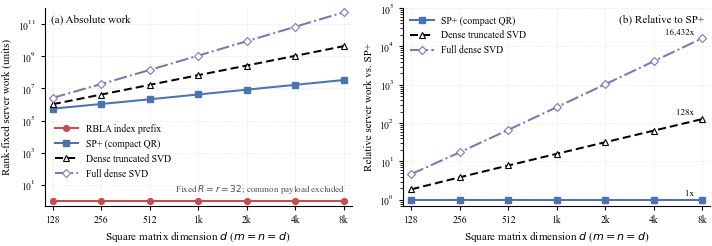

In [3]:
styles = {
    "RBLA index prefix": dict(color="#C44E52", marker="o", linestyle="-", zorder=2),
    "SP+ (compact QR)": dict(color="#4C72B0", marker="s", linestyle="-", zorder=3),
    "Dense truncated SVD": dict(
        color="black", marker="^", markerfacecolor="white",
        markeredgewidth=0.8, linestyle="--", dashes=(4, 2), zorder=4
    ),
    "Full dense SVD": dict(
        color="#8172B2", marker="D", markerfacecolor="white",
        markeredgewidth=0.8, linestyle="-.", zorder=5
    ),
}

RATIO_METHODS = ("SP+ (compact QR)", "Dense truncated SVD", "Full dense SVD")
x_tick_labels = ["128", "256", "512", "1k", "2k", "4k", "8k"]
fig, (ax_abs, ax_rel) = plt.subplots(1, 2, figsize=(7.16, 2.5))

for method in METHODS:
    group = complexity[complexity["method"] == method].sort_values("matrix_dimension")
    ax_abs.plot(group["matrix_dimension"], group["work_units"],
                label=method, **styles[method])
for method in RATIO_METHODS:
    group = complexity[complexity["method"] == method].sort_values("matrix_dimension")
    ax_rel.plot(group["matrix_dimension"], group["relative_to_sp_plus"],
                label=method, **styles[method])
    final = group.iloc[-1]
    ax_rel.annotate(
        f"{final.relative_to_sp_plus:,.0f}x",
        (final.matrix_dimension, final.relative_to_sp_plus),
        xytext=(-6, 3), textcoords="offset points", ha="right", fontsize=6.5
    )

for ax in (ax_abs, ax_rel):
    ax.set_xlabel(r"Square matrix dimension $d$ ($m=n=d$)")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xlim(DIMENSIONS[0] / 1.12, DIMENSIONS[-1] * 1.12)
    ax.set_xticks(DIMENSIONS)
    ax.set_xticklabels(x_tick_labels)
    ax.grid(True, which="major")
    ax.grid(False, which="minor")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", width=0.8, length=3)

ax_abs.set_ylabel("Rank-fixed server work (units)")
ax_abs.set_ylim(0.5, 10.0 ** np.ceil(np.log10(complexity["work_units"].max()) + 0.2))
ax_abs.legend(loc="upper left", bbox_to_anchor=(0.01, 0.45),
              handlelength=2.4, borderaxespad=0.3)
ax_abs.text(0.02, 0.97, "(a) Absolute work", transform=ax_abs.transAxes,
            ha="left", va="top", fontsize=8)
ax_abs.text(0.98, 0.05, r"Fixed $R=r=32$; common payload excluded",
            transform=ax_abs.transAxes, ha="right", va="bottom",
            fontsize=6.5, color="0.3")

ax_rel.set_ylabel("Relative server work vs. SP+")
ax_rel.set_ylim(0.7, 1e5)
ax_rel.legend(loc="upper left", handlelength=2.4, borderaxespad=0.3)
ax_rel.text(0.98, 0.97, "(b) Relative to SP+", transform=ax_rel.transAxes,
            ha="right", va="top", fontsize=8)
fig.tight_layout(pad=0.35, w_pad=1.1)

for suffix, kwargs in (
    ("pdf", {}),
    ("svg", {}),
    ("png", {"dpi": 600}),
):
    fig.savefig(OUTPUT_DIR / f"broadcast_complexity.{suffix}", **kwargs)

plt.show()

In [4]:
small = wide_cost.loc[DIMENSIONS[0]]
large = wide_cost.loc[DIMENSIONS[-1]]

print("Rank-fixed time-complexity comparison summary")
print(f"  fixed ranks: R={R}, r={CLIENT_RANK}")
print(f"  square dimensions: {DIMENSIONS.tolist()}")
for method in METHODS:
    print(f"  {method}: {int(small[method]):,} units at d={DIMENSIONS[0]}; "
          f"{int(large[method]):,} units at d={DIMENSIONS[-1]}; "
          f"fitted slope={slopes[method]:.3f}")
print(f"  dense/SP+ work ratio at d={DIMENSIONS[-1]}: "
      f"{large['Dense truncated SVD'] / large['SP+ (compact QR)']:.2f}x")
print(f"  full-SVD/SP+ work ratio at d={DIMENSIONS[-1]}: "
      f"{large['Full dense SVD'] / large['SP+ (compact QR)']:.2f}x")
print("  dense model: materialization + optimistic rank-r truncated SVD")
print("  full-SVD model: materialization + full dense SVD")
print(f"  all analytical checks passed: {all_checks_passed}")
print("  outputs:")
for path in sorted(OUTPUT_DIR.glob("broadcast_complexity.*")):
    print(f"    - {path.name}")

Rank-fixed time-complexity comparison summary
  fixed ranks: R=32, r=32
  square dimensions: [128, 256, 512, 1024, 2048, 4096, 8192]
  RBLA index prefix: 1 units at d=128; 1 units at d=8192; fitted slope=0.000
  SP+ (compact QR): 557,056 units at d=128; 33,587,200 units at d=8192; fitted slope=0.997
  Dense truncated SVD: 1,048,576 units at d=128; 4,294,967,296 units at d=8192; fitted slope=2.000
  Full dense SVD: 2,621,440 units at d=128; 551,903,297,536 units at d=8192; fitted slope=2.987
  dense/SP+ work ratio at d=8192: 127.88x
  full-SVD/SP+ work ratio at d=8192: 16431.95x
  dense model: materialization + optimistic rank-r truncated SVD
  full-SVD model: materialization + full dense SVD
  all analytical checks passed: True
  outputs:
    - broadcast_complexity.csv
    - broadcast_complexity.pdf
    - broadcast_complexity.png
    - broadcast_complexity.svg


## Space-complexity comparison

This section counts algorithm-specific auxiliary scalar elements while excluding the common input factors and final transmitted rank-$r$ payload. RBLA slicing is treated as a constant-size view. Compact SP+ counts the two thin-QR bases, canonical output factors, five $R\times R$ matrices, and the singular-value vector. The truncated dense path counts the dense update plus rank-$r$ working bases; full SVD counts the dense update and reduced full-SVD factors. Library-specific scratch buffers are not included.

$$M_{\mathrm{RBLA}}=1,$$

$$M_{\mathrm{SP+}}=2(m+n)R+5R^2+R,$$

$$M_{\mathrm{DenseTrunc}}=mn+(m+n)r+r,$$

$$M_{\mathrm{FullSVD}}=mn+(m+n)k+k,\qquad k=\min(m,n).$$

,check,passed
0,RBLA auxiliary space is constant,True
1,large-d SP+ space slope is approximately one,True
2,large-d truncated-SVD space slope is approxima...,True
3,large-d full-SVD space slope is approximately two,True
4,full SVD storage exceeds truncated-SVD storage,True


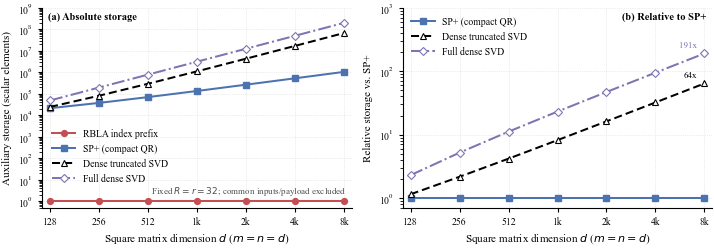

Space-complexity comparison summary
  RBLA index prefix: 1 elements at d=128; 1 elements at d=8192; fitted slope=0.000
  SP+ (compact QR): 21,536 elements at d=128; 1,053,728 elements at d=8192; fitted slope=0.984
  Dense truncated SVD: 24,608 elements at d=128; 67,633,184 elements at d=8192; fitted slope=1.975
  Full dense SVD: 49,280 elements at d=128; 201,334,784 elements at d=8192; fitted slope=2.000
  all analytical checks passed: True
  saved: broadcast_space_complexity.csv, broadcast_space_complexity.pdf/svg/png


In [5]:
SPACE_EXPRESSIONS = {
    "RBLA index prefix": "1 (constant-size prefix view)",
    "SP+ (compact QR)": "2(m+n)R + 5R^2 + R",
    "Dense truncated SVD": "mn + (m+n)r + r",
    "Full dense SVD": "mn + (m+n)k + k",
}
SPACE_ORDERS = {
    "RBLA index prefix": "O(1)",
    "SP+ (compact QR)": "O(m+n) for fixed R",
    "Dense truncated SVD": "O(mn) for fixed r",
    "Full dense SVD": "O(mn + (m+n)min(m,n))",
}

space_records = []
for dimension in DIMENSIONS:
    m = n = int(dimension)
    k = min(m, n)
    common_payload = (m + n) * CLIENT_RANK
    storage = {
        "RBLA index prefix": 1,
        "SP+ (compact QR)": 2 * (m + n) * R + 5 * R**2 + R,
        "Dense truncated SVD": m * n + (m + n) * CLIENT_RANK + CLIENT_RANK,
        "Full dense SVD": m * n + (m + n) * k + k,
    }
    for method in METHODS:
        space_records.append({
            "matrix_dimension": dimension, "d_out": m, "d_in": n,
            "R": R, "r": CLIENT_RANK, "method": method,
            "auxiliary_scalar_elements": int(storage[method]),
            "common_payload_scalars_excluded": int(common_payload),
            "space_expression": SPACE_EXPRESSIONS[method],
            "asymptotic_space_order": SPACE_ORDERS[method],
            "space_scope": "algorithm-specific auxiliary tensors",
        })

space_complexity = pd.DataFrame.from_records(space_records)
wide_space = space_complexity.pivot(
    index="matrix_dimension", columns="method", values="auxiliary_scalar_elements"
)
sp_space_by_dimension = wide_space["SP+ (compact QR)"].to_dict()
space_complexity["relative_to_sp_plus"] = [
    row.auxiliary_scalar_elements / sp_space_by_dimension[row.matrix_dimension]
    for row in space_complexity.itertuples(index=False)
]

def fitted_space_slope(method, tail=4):
    x = wide_space.index.to_numpy(dtype=float)[-tail:]
    y = wide_space[method].to_numpy(dtype=float)[-tail:]
    return float(np.polyfit(np.log(x), np.log(y), 1)[0])

space_slopes = {method: fitted_space_slope(method) for method in METHODS}
space_checks = {
    "RBLA auxiliary space is constant": bool((wide_space["RBLA index prefix"] == 1).all()),
    "large-d SP+ space slope is approximately one": 0.95 <= space_slopes["SP+ (compact QR)"] <= 1.05,
    "large-d truncated-SVD space slope is approximately two": 1.95 <= space_slopes["Dense truncated SVD"] <= 2.05,
    "large-d full-SVD space slope is approximately two": 1.95 <= space_slopes["Full dense SVD"] <= 2.05,
    "full SVD storage exceeds truncated-SVD storage": bool(
        (wide_space["Full dense SVD"] > wide_space["Dense truncated SVD"]).all()
    ),
}
space_all_checks_passed = all(space_checks.values())
space_complexity["analytical_checks_passed"] = space_all_checks_passed
space_csv_path = OUTPUT_DIR / "broadcast_space_complexity.csv"
space_complexity.to_csv(space_csv_path, index=False)
display(pd.DataFrame({"check": space_checks.keys(), "passed": space_checks.values()}))
assert space_all_checks_passed, [name for name, passed in space_checks.items() if not passed]

fig, (ax_abs, ax_ratio) = plt.subplots(1, 2, figsize=(7.16, 2.5))
for method in METHODS:
    group = space_complexity[space_complexity["method"] == method].sort_values("matrix_dimension")
    ax_abs.plot(group["matrix_dimension"], group["auxiliary_scalar_elements"],
                label=method, **styles[method])
for method in RATIO_METHODS:
    group = space_complexity[space_complexity["method"] == method].sort_values("matrix_dimension")
    ax_ratio.plot(group["matrix_dimension"], group["relative_to_sp_plus"],
                  label=method, **styles[method])
    endpoint = group.iloc[-1]
    if method != "SP+ (compact QR)":
        ax_ratio.annotate(f"{endpoint.relative_to_sp_plus:,.0f}x",
                          (endpoint.matrix_dimension, endpoint.relative_to_sp_plus),
                          xytext=(-5, 3), textcoords="offset points",
                          ha="right", va="bottom", fontsize=6.5,
                          color=styles[method]["color"])

for ax in (ax_abs, ax_ratio):
    ax.set_xlabel(r"Square matrix dimension $d$ ($m=n=d$)")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xlim(DIMENSIONS[0] / 1.12, DIMENSIONS[-1] * 1.12)
    ax.set_xticks(DIMENSIONS)
    ax.set_xticklabels(["128", "256", "512", "1k", "2k", "4k", "8k"])
    ax.grid(True, which="major")
    ax.grid(False, which="minor")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", width=0.8, length=3)

min_storage = space_complexity["auxiliary_scalar_elements"].min()
max_storage = space_complexity["auxiliary_scalar_elements"].max()
ax_abs.set_ylabel("Auxiliary storage (scalar elements)")
ax_abs.set_ylim(0.5 * 10.0 ** np.floor(np.log10(min_storage)),
                10.0 ** np.ceil(np.log10(max_storage) + 0.2))
ax_abs.legend(loc="upper left", bbox_to_anchor=(0.01, 0.43),
              handlelength=2.4, borderaxespad=0.3)
ax_abs.text(0.02, 0.98, "(a) Absolute storage", transform=ax_abs.transAxes,
            ha="left", va="top", fontsize=7.5, fontweight="bold")
ax_abs.text(0.98, 0.05, r"Fixed $R=r=32$; common inputs/payload excluded",
            transform=ax_abs.transAxes, ha="right", va="bottom",
            fontsize=6.5, color="0.3")
ax_ratio.set_ylabel("Relative storage vs. SP+")
ax_ratio.set_ylim(0.7, 1e3)
ax_ratio.legend(loc="upper left", handlelength=2.4)
ax_ratio.text(0.98, 0.98, "(b) Relative to SP+", transform=ax_ratio.transAxes,
              ha="right", va="top", fontsize=7.5, fontweight="bold")
fig.tight_layout(pad=0.25, w_pad=1.0)
for suffix, kwargs in (("pdf", {}), ("svg", {}), ("png", {"dpi": 600})):
    fig.savefig(OUTPUT_DIR / f"broadcast_space_complexity.{suffix}", **kwargs)
plt.show()

small_space = wide_space.loc[DIMENSIONS[0]]
large_space = wide_space.loc[DIMENSIONS[-1]]
print("Space-complexity comparison summary")
for method in METHODS:
    print(f"  {method}: {int(small_space[method]):,} elements at d={DIMENSIONS[0]}; "
          f"{int(large_space[method]):,} elements at d={DIMENSIONS[-1]}; "
          f"fitted slope={space_slopes[method]:.3f}")
print(f"  all analytical checks passed: {space_all_checks_passed}")
print(f"  saved: {space_csv_path.name}, broadcast_space_complexity.pdf/svg/png")